# Task 4: Regression Analysis

### 1. Dataset Selection

#### The dataset is loaded, and its structure is examined to understand column types and data availability. Missing values are checked to determine if any preprocessing is required. This ensures the dataset is clean before further analysis.

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("house_prices.csv")  
print(df.info())  
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   House_ID             100 non-null    object 
 1   Location             100 non-null    object 
 2   Size                 100 non-null    int64  
 3   Number_of_Rooms      100 non-null    int64  
 4   Number_of_Bathrooms  100 non-null    int64  
 5   Year                 100 non-null    int64  
 6   Distance             100 non-null    float64
 7   Nearby_Amenities     100 non-null    int64  
 8   Price                100 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 7.2+ KB
None
House_ID               0
Location               0
Size                   0
Number_of_Rooms        0
Number_of_Bathrooms    0
Year                   0
Distance               0
Nearby_Amenities       0
Price                  0
dtype: int64


In [112]:
print(df.columns)

Index(['House_ID', 'Location', 'Size', 'Number_of_Rooms',
       'Number_of_Bathrooms', 'Year', 'Distance', 'Nearby_Amenities', 'Price'],
      dtype='object')


## 2. Load and Explore

#### Numerical missing values are filled with the median, and categorical ones with the mode. This ensures a complete dataset without skewing distributions.

In [113]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

#### Histograms are plotted for numerical columns to visualize their distributions. This helps identify skewness, trends, and potential outliers in the data.

array([[<Axes: title={'center': 'Size'}>,
        <Axes: title={'center': 'Number_of_Rooms'}>,
        <Axes: title={'center': 'Number_of_Bathrooms'}>],
       [<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Distance'}>,
        <Axes: title={'center': 'Nearby_Amenities'}>],
       [<Axes: title={'center': 'Price'}>, <Axes: >, <Axes: >]],
      dtype=object)

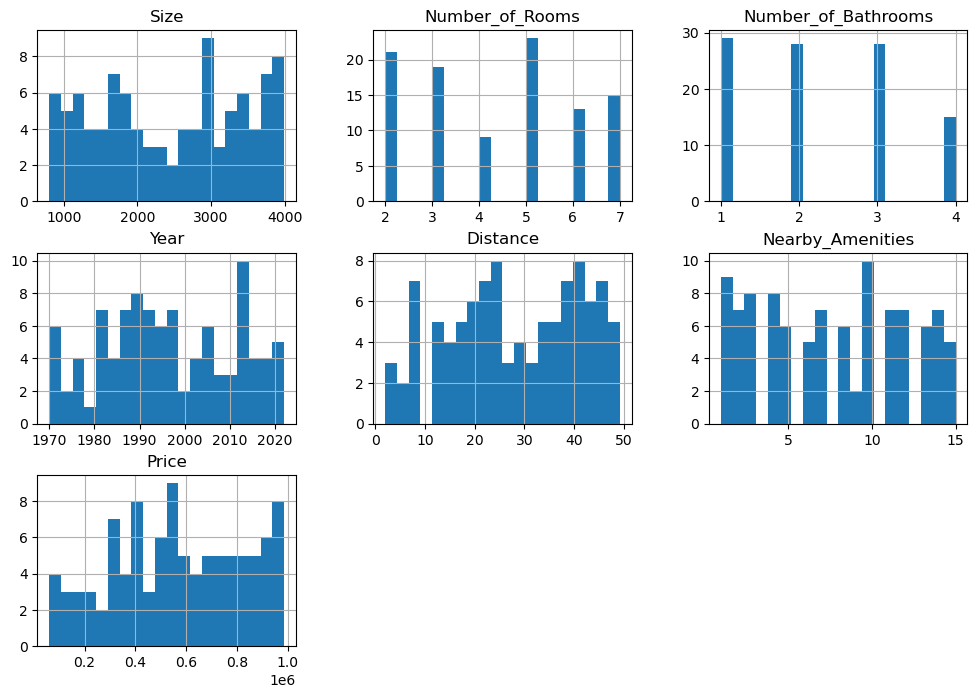

In [114]:
numerical_cols = ["Size", "Number_of_Rooms", "Number_of_Bathrooms", "Year", "Distance", "Nearby_Amenities", "Price"]
df[numerical_cols].hist(figsize=(12, 8), bins=20, layout=(3, 3))

#### A boxplot is created to detect outliers and understand value distributions across numerical features. It visually highlights data spread, central tendencies, and extreme values.

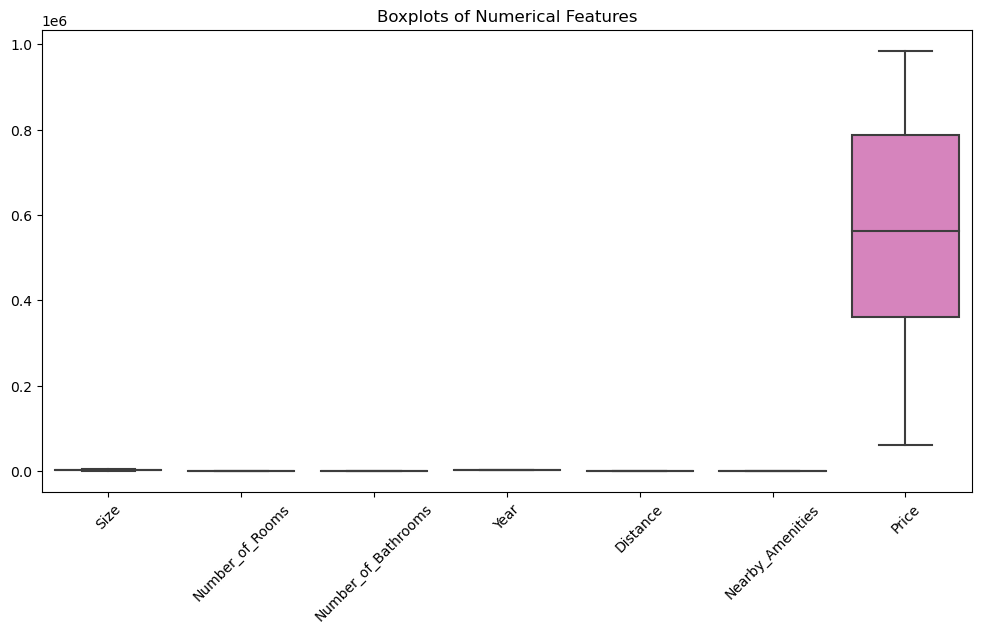

In [116]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

## 3. Data Preprocessing

#### Numerical features are scaled using Min-Max scaling to bring values into a comparable range. One-hot encoding converts the categorical Location column into numerical form for machine learning models. This ensures standardized inputs for better model performance.

In [117]:
df = df.drop(columns=["House_ID"])

In [118]:
import warnings
warnings.filterwarnings("ignore")

scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [119]:
encoder = OneHotEncoder(drop="first", sparse=False)
location_encoded = encoder.fit_transform(df[["Location"]])
location_df = pd.DataFrame(location_encoded, columns=encoder.get_feature_names_out(["Location"]))

## 4. Feature Selection

#### The encoded location data is merged back, replacing the original column. A correlation heatmap is plotted to analyze relationships between features and identify highly correlated variables. This helps in feature selection for model training.

In [120]:
df = pd.concat([df.drop(columns=["Location"]), location_df], axis=1)
correlation_matrix = df.corr()

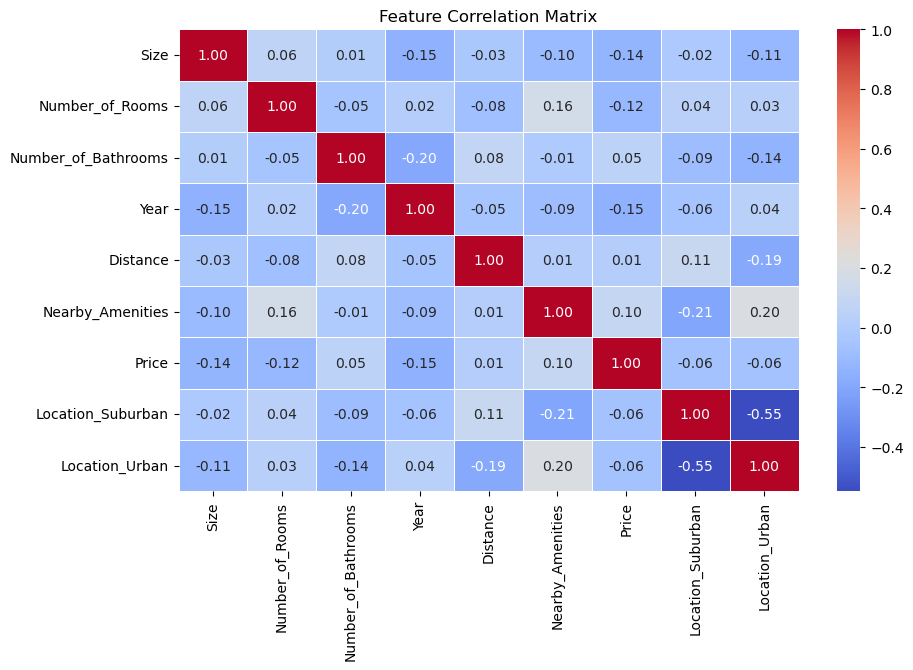

In [121]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

In [122]:
correlation_with_price = correlation_matrix["Price"].abs().sort_values(ascending=False)
print("Feature correlations with Price:\n", correlation_with_price)

Feature correlations with Price:
 Price                  1.000000
Year                   0.146335
Size                   0.135278
Number_of_Rooms        0.117910
Nearby_Amenities       0.098023
Location_Urban         0.064550
Location_Suburban      0.060499
Number_of_Bathrooms    0.054774
Distance               0.014981
Name: Price, dtype: float64


## 5. Model Training and Evaluation

In [123]:
X = df.drop(columns=["Price"])
y = df["Price"]

#### The dataset is split into training (80%) and testing (20%) sets to ensure proper model evaluation. A linear regression model is then trained on the training data to learn relationships between features and the target variable.

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#### The trained model makes predictions on the test set, and performance is evaluated. RMSE measures prediction error, while R² indicates how well the model explains price variability.

In [125]:
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

In [126]:
print(f"Linear Regression - RMSE: {rmse:.4f}, R²: {r2:.4f}")

Linear Regression - RMSE: 0.3221, R²: -0.0160
